In [1]:
import time
from typing import List
import numpy as np
import torch
import torch.nn as nn
import torchode
from pathlib import Path
import pickle

from scipy.integrate import solve_ivp as sp_solve_ivp
from ftnode.data import TrialsDataset
from tqdm.auto import tqdm

from sklearn.preprocessing import MinMaxScaler
from ftnode.utils import set_global_seed, _load_loop_wrapper
from ftnode.data import TrialsDataset
from ftnode.node import (
    FTNODE, FeluSigmoidMLP,FeluSigmoidMLPfeaturized,
     GeluSigmoidMLPfeaturized,
)

import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams['font.family']= 'serif'

device = 'cpu'
seed = 1234
set_global_seed(seed=seed)
random_state = 67

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
def hysteresis_ode(t,x,lam):
    return lam+x-x**3

In [3]:
n_lam = 51
n_traj = 51
lams = np.linspace(-1,1,n_lam)
xs = np.linspace(-2,2,n_traj)


In [4]:
t_max = 0.25
n_colloc = 101


Xs = []
Us = []
t = np.linspace(0,t_max,n_colloc)
for lami in tqdm(lams):
    for x0 in xs:
        sol = sp_solve_ivp(
            hysteresis_ode,
            t_span = [0,t_max],
            y0 = np.array(x0).reshape(-1),
            t_eval = np.linspace(0,t_max,n_colloc),
            args = (lami,)
        )

        Xs.append(sol.y.T)
        Us.append([lami])
Xs = np.array(Xs)
Us = np.array(Us)

  0%|          | 0/51 [00:00<?, ?it/s]

In [5]:
dXs = np.zeros_like(Xs)
T = t[np.newaxis,:,np.newaxis]
X_diff = Xs[:,2:,:] - Xs[:,:-2,:]
T_diff = T[:,2:,:] - T[:,:-2,:]

dXs[:,1:-1,:] = X_diff/T_diff
dXs[:,0,:] = (Xs[:,1,:] - Xs[:,0,:]) / (T[:,1,:] - T[:,0,:])
dXs[:,-1,:] = (Xs[:,-1,:] - Xs[:,-2,:]) / (T[:,-1,:] - T[:,-2,:])

In [6]:
scaler = MinMaxScaler(feature_range=(-1,1))
Xs_scaled = scaler.fit_transform(Xs.reshape(-1,1).reshape(-1,1)).reshape(-1,n_colloc,1)

In [7]:
dX_tensor = [
    torch.tensor(dxi,dtype=torch.float32,device=device) for dxi in dXs
]
X_tensor = [
    torch.tensor(xi,dtype=torch.float32,device=device) for xi in Xs_scaled
]
U_tensor = [
    torch.tensor(ui,dtype=torch.float32,device=device) for ui in Us
]

T_tensor = [
    torch.tensor(t,dtype=torch.float32, device=device) for _ in range(len(Xs))
]

In [8]:
class GradDataset(torch.utils.data.Dataset):
    def __init__(self, dX: List, X: List, T: List, U: List):
        self.dX = dX
        self.X = X
        self.T = T
        self.U = U
        # self.trans_idx = Transient_idx

    def __len__(self):
        return len(self.dX)

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError(
                f"Index {idx} is out of bounds of dataset size: {len(self)}."
            )

        dXi = self.dX[idx]
        Xi = self.X[idx]
        ti = self.T[idx]
        ui = self.U[idx]

        return dXi, Xi, ti, ui

dataset = GradDataset(dX = dX_tensor,X = X_tensor, T = T_tensor, U = U_tensor)

# Run $k$-Folds Cross-validation

In [9]:
k_folds = 10

In [10]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, SubsetRandomSampler
import time
import copy

In [11]:
avg_best_val_losses = []
avg_best_train_losses = []

In [12]:
# --- Configuration ---
k_folds = k_folds
n_epochs = 200  
batch_size = 50 
learning_rate = 1e-2
print_every = 10
_precision = 6
random_state = random_state
solve_method = 'tsit5'


kfold = KFold(n_splits=k_folds, shuffle=True, random_state=random_state)

val_results = []
train_results = []

def get_fresh_model_components():
    f = FeluSigmoidMLP(
        dims=[1,20,20,20, 1],
        activation=nn.SiLU(),
        lower_bound=-5,
        upper_bound=-0.1,
        init_type=None
    )


    g = GeluSigmoidMLPfeaturized(
        dims=[6, 20,20,20,1],
        activation=nn.SiLU(),
        lower_bound=-2,
        upper_bound=2,
        freq_sample_step=1,
        feat_lower_bound=-1.5,
        feat_upper_bound=1.5,
        init_type=None
    )

    model = FTNODE(f, g).to(device)
    return f, g, model 

# ==========================================
# K-Fold Loop
# ==========================================
for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset)):
    print(f'\n--- FOLD {fold+1}/{k_folds} ---')

    fold_seed = random_state + fold
    set_global_seed(fold_seed)

    # 1. Re-initialize Model & Optimizer for this fold
    f_fold, g_fold, model_fold = get_fresh_model_components()
    model_fold.train() 
    
    loss_criteria = nn.MSELoss()
    

    opt = torch.optim.Adam(
        list(f_fold.parameters()) + list(g_fold.parameters()), 
        lr=learning_rate
    )
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=10
    )

    # 2. Create DataLoaders for this fold
    train_subsampler = SubsetRandomSampler(train_ids)
    val_subsampler = SubsetRandomSampler(val_ids)

    trainloader = DataLoader(dataset, batch_size=batch_size, sampler=train_subsampler)
    valloader = DataLoader(dataset, batch_size=batch_size, sampler=val_subsampler)

    # 3. Training & Validation Loop
    best_val_loss = float('inf')
    fold_losses = []

    for epoch in tqdm(range(n_epochs), desc=f"Fold {fold+1}"):
        t1 = time.time()
        
        # --- TRAINING ---
        model_fold.train()
        train_loss = 0.0
        
        for batch_idx, (dXi, Xi, ti, ui) in enumerate(trainloader):
            x0i = Xi[:, 0, :]
            
            # ui_expanded = ui.unsqueeze(dim=1).expand(Xi.shape)
            # u_func = lambda t: ui_expanded
            u_func = lambda t: ui
            func = lambda t, x: model_fold(t, x, u_func)

            opt.zero_grad()
            sol = torchode.solve_ivp(
                f=func,
                y0=x0i,
                t_eval=ti.squeeze(),
                method=solve_method,
            )
            
            Xi_pred = sol.ys


            # loss = loss_criteria(dXi, dXi_pred)
            loss = loss_criteria(Xi, Xi_pred)
                
            loss.backward()
            opt.step()
            
            train_loss += loss.item()
        
        train_loss /= len(trainloader)

        # --- VALIDATION ---
        model_fold.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_idx, (dXi, Xi, ti, ui) in enumerate(valloader):
                x0i = Xi[:, 0, :]
                # ui_expanded = ui.unsqueeze(dim=1).expand(Xi.shape)
                # u_func = lambda t: ui_expanded
                u_func = lambda t: ui
                func = lambda t, x: model_fold(t, x, u_func)

                sol = torchode.solve_ivp(
                    f=func,
                    y0=x0i,
                    t_eval=ti.squeeze(),
                    method=solve_method,
                )

                Xi_pred = sol.ys


                # loss = loss_criteria(dXi, dXi_pred)
                loss = loss_criteria(Xi, Xi_pred)
                val_loss += loss.item()
        
        val_loss /= len(valloader)
        
        # --- SCHEDULER & LOGGING ---
        epoch_time = time.time() - t1
        
        # Step scheduler based on VALIDATION loss (standard practice)
        scheduler.step(val_loss) 
        cur_lr = opt.param_groups[0]['lr']

        if epoch <= 5 or epoch % print_every == 0 or epoch == n_epochs - 1:
            print(
                f"Epoch {epoch}: "
                f"Train Loss = {train_loss:.{_precision}e}, "
                f"Val Loss = {val_loss:.{_precision}e}, "
                f"Time = {epoch_time:.{_precision}e}, "
                f"lr = {cur_lr:.{_precision}e}"
            )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_train_loss = train_loss
            best_fold = fold
            
    print(f"Fold {fold+1} Best Val Loss: {best_val_loss:.{_precision}e}")
    val_results.append(best_val_loss)
    train_results.append(best_val_train_loss)

# --- SUMMARY ---
print("\nK-Fold Cross Validation Results:")
avg_loss = np.mean(val_results)
avg_train_loss = np.mean(train_results)
print(f"Average Best Validation Loss: {avg_loss:.{_precision}e}")
avg_best_val_losses.append(avg_loss)
avg_best_train_losses.append(avg_train_loss)
avg_best_val_losses, np.argmin(avg_best_val_losses)


--- FOLD 1/10 ---
[Seed] Deterministic mode enabled (may reduce speed).


Fold 1:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 0: Train Loss = 3.520822e-03, Val Loss = 7.882390e-04, Time = 3.454068e+00, lr = 1.000000e-02
Epoch 1: Train Loss = 4.097238e-04, Val Loss = 2.094790e-04, Time = 3.656139e+00, lr = 1.000000e-02
Epoch 2: Train Loss = 1.451061e-04, Val Loss = 9.824478e-05, Time = 3.539587e+00, lr = 1.000000e-02
Epoch 3: Train Loss = 9.528119e-05, Val Loss = 6.467680e-05, Time = 3.584270e+00, lr = 1.000000e-02
Epoch 4: Train Loss = 7.890901e-05, Val Loss = 5.403856e-05, Time = 3.567417e+00, lr = 1.000000e-02
Epoch 5: Train Loss = 6.155351e-05, Val Loss = 4.522705e-05, Time = 3.509823e+00, lr = 1.000000e-02
Epoch 10: Train Loss = 3.536535e-05, Val Loss = 1.887009e-05, Time = 3.626633e+00, lr = 1.000000e-02
Epoch 20: Train Loss = 5.010504e-06, Val Loss = 3.575502e-06, Time = 3.230905e+00, lr = 1.000000e-02
Epoch 30: Train Loss = 1.951414e-06, Val Loss = 1.277731e-06, Time = 3.020177e+00, lr = 1.000000e-02
Epoch 40: Train Loss = 1.596904e-06, Val Loss = 1.760101e-06, Time = 2.961884e+00, lr = 1.000000e

Fold 2:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 0: Train Loss = 3.255542e-03, Val Loss = 5.953125e-04, Time = 3.088374e+00, lr = 1.000000e-02
Epoch 1: Train Loss = 3.769038e-04, Val Loss = 1.564160e-04, Time = 3.736156e+00, lr = 1.000000e-02
Epoch 2: Train Loss = 1.328831e-04, Val Loss = 1.306954e-04, Time = 3.291233e+00, lr = 1.000000e-02
Epoch 3: Train Loss = 9.628998e-05, Val Loss = 6.199360e-05, Time = 3.287462e+00, lr = 1.000000e-02
Epoch 4: Train Loss = 5.662581e-05, Val Loss = 5.277058e-05, Time = 3.429617e+00, lr = 1.000000e-02
Epoch 5: Train Loss = 4.250678e-05, Val Loss = 4.546226e-05, Time = 3.496751e+00, lr = 1.000000e-02
Epoch 10: Train Loss = 1.108596e-05, Val Loss = 1.035269e-05, Time = 3.260241e+00, lr = 1.000000e-02
Epoch 20: Train Loss = 4.913654e-06, Val Loss = 3.739030e-06, Time = 3.166227e+00, lr = 1.000000e-02
Epoch 30: Train Loss = 1.724175e-06, Val Loss = 2.374921e-06, Time = 3.172514e+00, lr = 1.000000e-02
Epoch 40: Train Loss = 1.580901e-06, Val Loss = 2.579045e-06, Time = 3.049254e+00, lr = 1.000000e

...

Fold 9:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 0: Train Loss = 4.654138e-03, Val Loss = 9.377886e-04, Time = 3.051291e+00, lr = 1.000000e-02
Epoch 1: Train Loss = 5.490157e-04, Val Loss = 2.690845e-04, Time = 3.573152e+00, lr = 1.000000e-02
Epoch 2: Train Loss = 1.715469e-04, Val Loss = 1.114124e-04, Time = 3.453482e+00, lr = 1.000000e-02
Epoch 3: Train Loss = 9.322224e-05, Val Loss = 7.916323e-05, Time = 3.482234e+00, lr = 1.000000e-02
Epoch 4: Train Loss = 8.331150e-05, Val Loss = 5.937107e-05, Time = 3.439752e+00, lr = 1.000000e-02
Epoch 5: Train Loss = 6.513594e-05, Val Loss = 5.062915e-05, Time = 3.544095e+00, lr = 1.000000e-02
Epoch 10: Train Loss = 3.308380e-05, Val Loss = 3.182332e-05, Time = 3.439891e+00, lr = 1.000000e-02
Epoch 20: Train Loss = 7.104772e-06, Val Loss = 6.168911e-06, Time = 3.280623e+00, lr = 1.000000e-02
Epoch 30: Train Loss = 2.159738e-06, Val Loss = 2.947316e-06, Time = 3.153785e+00, lr = 1.000000e-02
Epoch 40: Train Loss = 1.009654e-05, Val Loss = 2.726427e-06, Time = 3.051144e+00, lr = 1.000000e

Fold 10:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 0: Train Loss = 3.616865e-03, Val Loss = 1.047644e-03, Time = 2.819108e+00, lr = 1.000000e-02
Epoch 1: Train Loss = 5.191863e-04, Val Loss = 2.765520e-04, Time = 3.542277e+00, lr = 1.000000e-02
Epoch 2: Train Loss = 1.918301e-04, Val Loss = 1.342080e-04, Time = 3.502000e+00, lr = 1.000000e-02
Epoch 3: Train Loss = 9.814187e-05, Val Loss = 7.098518e-05, Time = 3.713825e+00, lr = 1.000000e-02
Epoch 4: Train Loss = 6.569599e-05, Val Loss = 5.263554e-05, Time = 3.634699e+00, lr = 1.000000e-02
Epoch 5: Train Loss = 4.042880e-05, Val Loss = 3.537641e-05, Time = 3.657191e+00, lr = 1.000000e-02
Epoch 10: Train Loss = 1.265022e-05, Val Loss = 1.008357e-05, Time = 3.399471e+00, lr = 1.000000e-02
Epoch 20: Train Loss = 2.724265e-06, Val Loss = 2.139858e-06, Time = 3.217595e+00, lr = 1.000000e-02
Epoch 30: Train Loss = 2.426662e-06, Val Loss = 3.086657e-06, Time = 3.078223e+00, lr = 1.000000e-02
Epoch 40: Train Loss = 6.611638e-07, Val Loss = 4.354954e-07, Time = 3.082330e+00, lr = 1.000000e

([6.236810485837907e-08], 0)

In [13]:
Xi[Xi.isnan()]

tensor([])

In [14]:
Xi

tensor([[[-0.8400],
         [-0.8352],
         [-0.8304],
         ...,
         [-0.5803],
         [-0.5787],
         [-0.5772]],

        [[ 0.1200],
         [ 0.1190],
         [ 0.1181],
         ...,
         [ 0.0139],
         [ 0.0127],
         [ 0.0115]],

        [[ 0.0400],
         [ 0.0395],
         [ 0.0390],
         ...,
         [-0.0155],
         [-0.0162],
         [-0.0168]],

        ...,

        [[-0.9600],
         [-0.9533],
         [-0.9468],
         ...,
         [-0.6562],
         [-0.6547],
         [-0.6532]],

        [[ 1.0000],
         [ 0.9932],
         [ 0.9867],
         ...,
         [ 0.7147],
         [ 0.7135],
         [ 0.7123]],

        [[ 0.0400],
         [ 0.0388],
         [ 0.0377],
         ...,
         [-0.0876],
         [-0.0891],
         [-0.0905]]])

In [15]:
Xi_pred

tensor([[[-0.8400],
         [-0.8352],
         [-0.8305],
         ...,
         [-0.5794],
         [-0.5779],
         [-0.5764]],

        [[ 0.1200],
         [ 0.1190],
         [ 0.1181],
         ...,
         [ 0.0137],
         [ 0.0125],
         [ 0.0113]],

        [[ 0.0400],
         [ 0.0395],
         [ 0.0390],
         ...,
         [-0.0155],
         [-0.0162],
         [-0.0168]],

        ...,

        [[-0.9600],
         [-0.9533],
         [-0.9468],
         ...,
         [-0.6558],
         [-0.6543],
         [-0.6529]],

        [[ 1.0000],
         [ 0.9935],
         [ 0.9871],
         ...,
         [ 0.7141],
         [ 0.7129],
         [ 0.7117]],

        [[ 0.0400],
         [ 0.0388],
         [ 0.0377],
         ...,
         [-0.0879],
         [-0.0894],
         [-0.0909]]])

In [16]:
f = model_fold.f
f.eval()

FeluSigmoidMLP(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=1, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=1, bias=True)
    )
  )
)

In [17]:
xs = torch.tensor(np.linspace(-1,1,101),dtype=torch.float32).reshape(-1,1)

In [18]:
with torch.no_grad():
    f_out = f(xs)

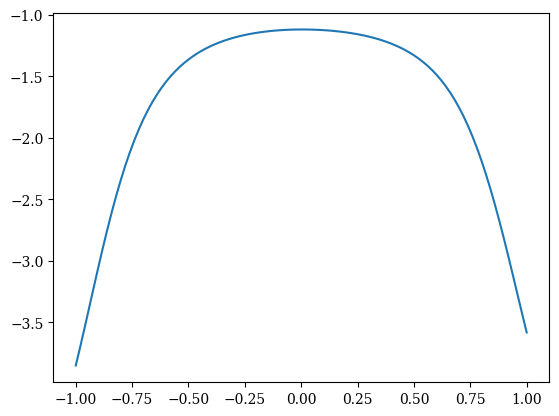

In [20]:
plt.plot(xs,f_out)